# Atelier Seaborn — Analyse exploratoire des données IoT

Ce notebook explore les mesures de capteurs IoT (température, humidité, pression, consommation énergétique) à l'aide de Seaborn, en s'appuyant sur les traitements réalisés précédemment avec NumPy, Pandas et Matplotlib.

## 1. Installation et imports des bibliothèques

In [1]:
pip install seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sns.set_theme(style="darkgrid") # Set the theme for seaborn plots

## 2. Chargement des données

Import du fichier `mesures_capteurs.csv` dans un DataFrame pandas.

In [ ]:
df=pd.read_csv("../data/mesures_capteurs.csv")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [6]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 — Distribution d'une variable avec `histplot()`

On étudie la distribution de la température à l'aide d'un histogramme.

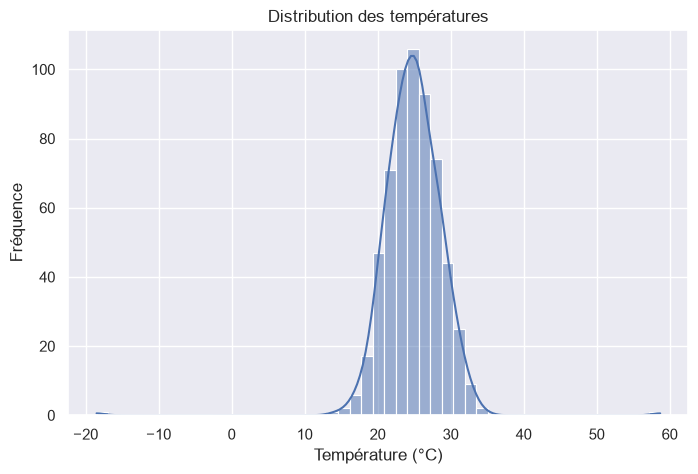

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", kde=True) #ajoute une courbe KDE (Kernel Density Estimate), qui représente de manière lissée la distribution des températures.
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

In [8]:
print("Moyenne :", df["temperature"].mean())
print("Médiane :", df["temperature"].median())
print("Mode :", df["temperature"].mode()[0])

Moyenne : 24.87831385642738
Médiane : 24.86
Mode : 23.89


**2) Autour de quelle valeur les températures sont concentrées ?**

Les températures sont concentrées autour de **25°C**, ce qui correspond au pic de 
l'histogramme et au sommet de la courbe KDE. La grande majorité des mesures se situent 
entre 20°C et 30°C.

**3) La distribution semble-t-elle symétrique ?**

Oui, la distribution semble globalement **symétrique** (en forme de cloche, proche d'une 
loi normale). La majorité des mesures sont concentrées autour de 25°C, avec une 
répartition à peu près équilibrée de part et d'autre du pic.

**4) Existe-t-il des valeurs extrêmes ?**

Oui, on observe quelques **valeurs extrêmes (outliers)** : une mesure isolée autour de 
**-20°C** et une autre autour de **58°C**, très éloignées du reste des données 
(concentrées entre 15°C et 35°C). Ces valeurs pourraient correspondre à des erreurs de 
capteur ou à des anomalies à vérifier.

**5) Modifier le nombre de classes**

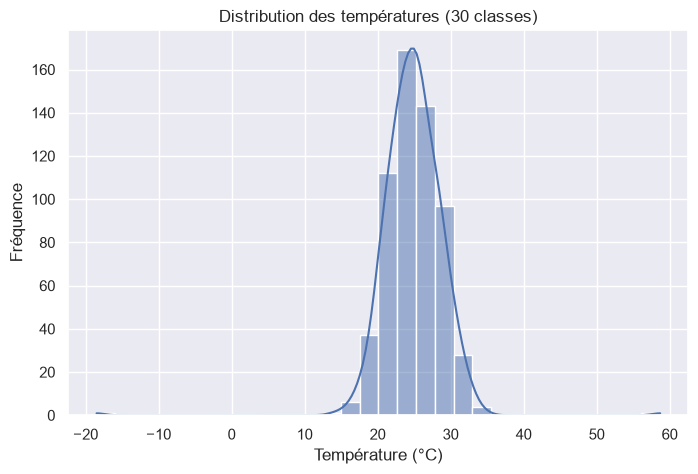

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=30, kde=True)
plt.title("Distribution des températures (30 classes)")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

**6) Afficher la distribution des températures par bâtiment**

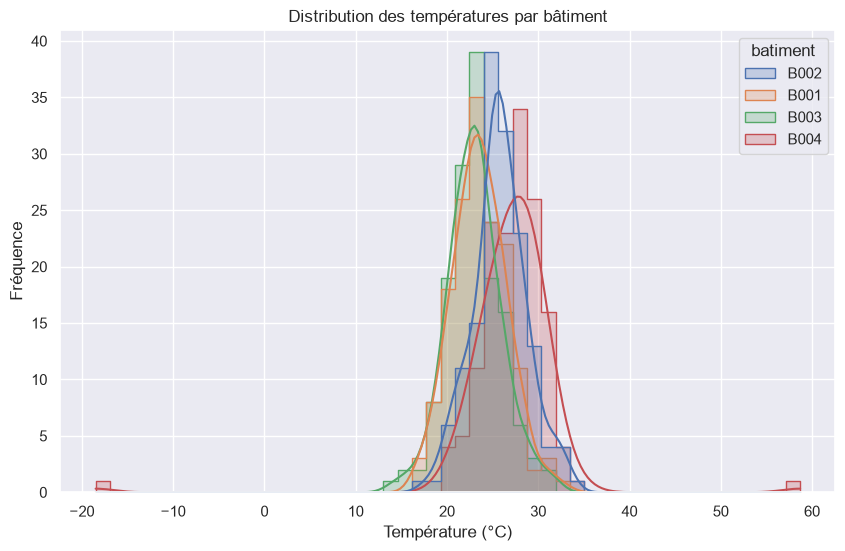

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

## Partie 2 — Distribution d'une variable avec `kdeplot()`

Le `kdeplot()` affiche une estimation lissée de la densité de probabilité, utile pour 
mieux visualiser la forme globale d'une distribution sans l'effet "en escalier" de 
l'histogramme.

**1) Afficher la distribution des températures**

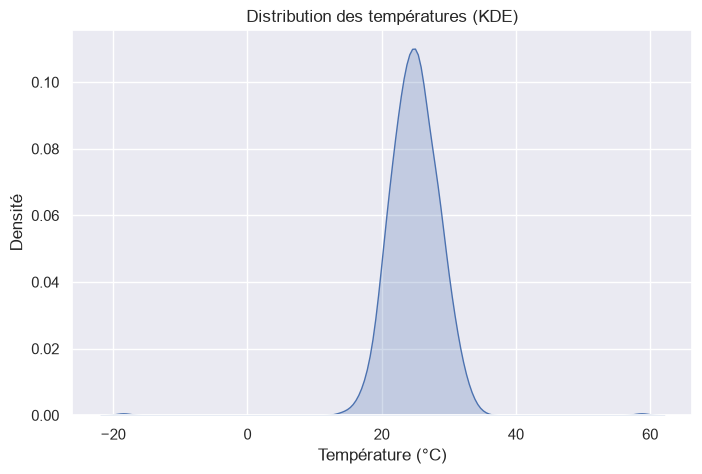

In [11]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Distribution des températures (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

**2) Afficher la distribution des températures par bâtiment**

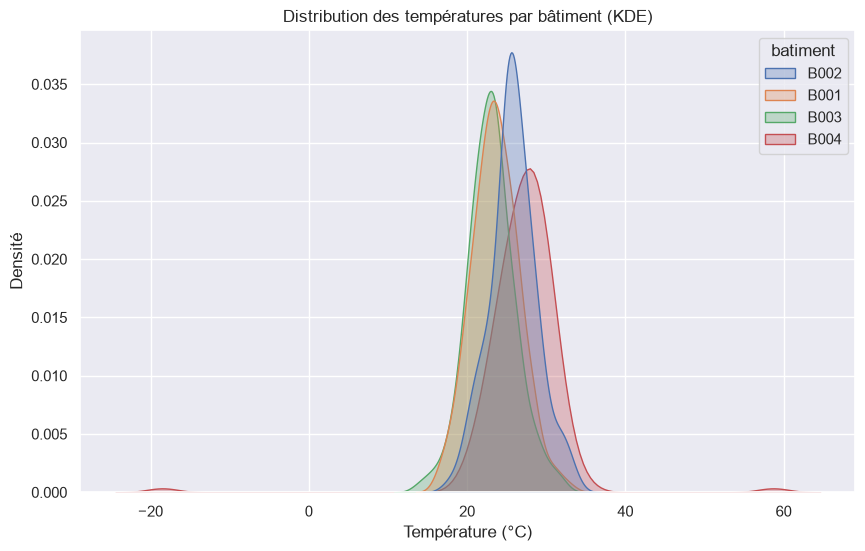

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3)
plt.title("Distribution des températures par bâtiment (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

## Partie 3 — Distribution d'une variable avec `boxplot()`



## 1) Afficher la distribution des températures

Afficher la distribution des températures à l'aide d'un histogramme (`histplot`).

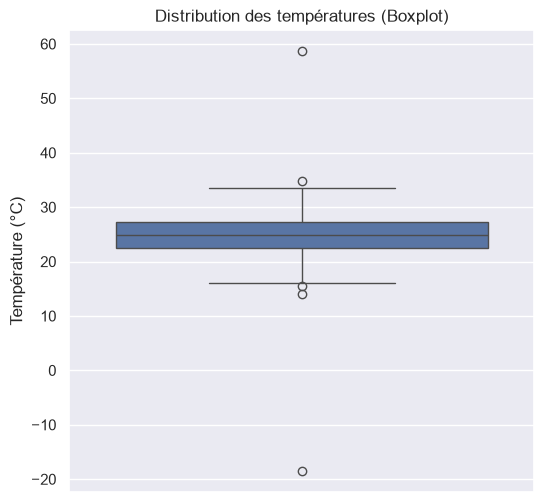

In [15]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, y="temperature")
plt.title("Distribution des températures (Boxplot)")
plt.ylabel("Température (°C)")
plt.show()

## 2) Afficher la distribution des températures par bâtiment

Afficher la distribution des températures pour chaque bâtiment afin de comparer leurs différentes distributions.

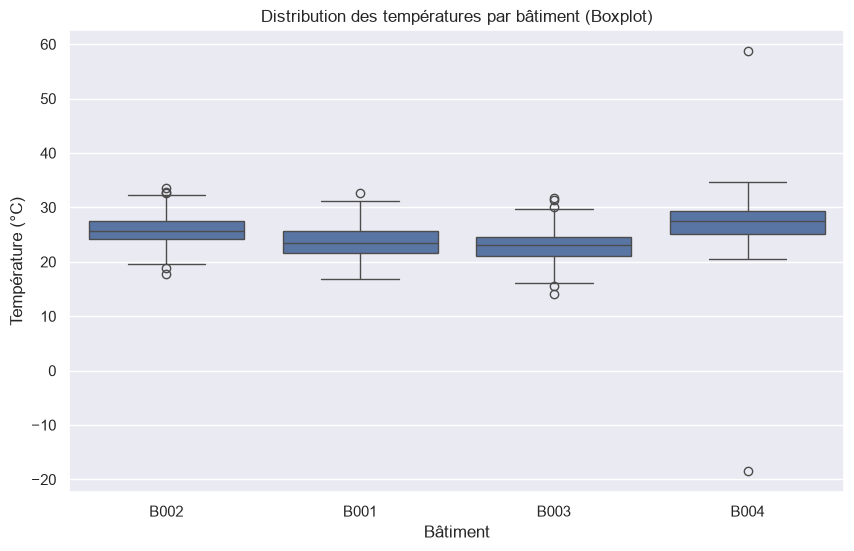

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Distribution des températures par bâtiment (Boxplot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

**3) Pour chaque bâtiment :**



### 3a) Médiane des températures pour chaque bâtiment

D'après le boxplot, les médianes sont approximativement :

- **B001 :** autour de **24 °C**
- **B002 :** autour de **26 °C**
- **B003 :** autour de **23 °C**
- **B004 :** autour de **28 °C**

On constate que **B004 possède la médiane la plus élevée**, tandis que **B003 possède la médiane la plus faible**.

### 3b) Dispersion des températures pour chaque bâtiment

D'après le boxplot :

- **B001 :** dispersion moyenne
- **B002 :** dispersion faible
- **B003 :** dispersion moyenne
- **B004 :** dispersion légèrement plus élevée

**B004 présente donc la plus forte dispersion, tandis que B002 présente la plus faible.**

### 3c) Valeurs extrêmes

D'après le boxplot :

- **B001 :** une valeur extrême est visible en haut, autour de **30 °C**.
- **B003 et B002 :** plusieurs valeurs extrêmes sont visibles, environ **2 en haut autour de 30 °C** et **2 en bas autour de 20 °C**.
- **B004 :** aucune valeur extrême n'est visible.

Les valeurs extrêmes correspondent aux points situés en dehors des moustaches du boxplot.

### 4) Quels bâtiments ont les valeurs les plus extrêmes ?

D'après le boxplot, **B003 et B002 possède les valeurs les plus extrêmes**, avec plusieurs points éloignés des moustaches, autour de **20 °C et 30 °C**.

**B001** possède également une valeur extrême autour de **30 °C**, mais moins importante que B003.

Ainsi, **B003 et B002 sont les bâtiment présentant les valeurs les plus extrêmes**.

## Partie 4 — Distribution d'une variable avec `violinplot()`

Le `violinplot()` combine les informations du boxplot (médiane, quartiles) avec celles 
du kdeplot (forme de la distribution), offrant une vue plus riche de la répartition 
des données.

**1) Afficher la distribution des températures**

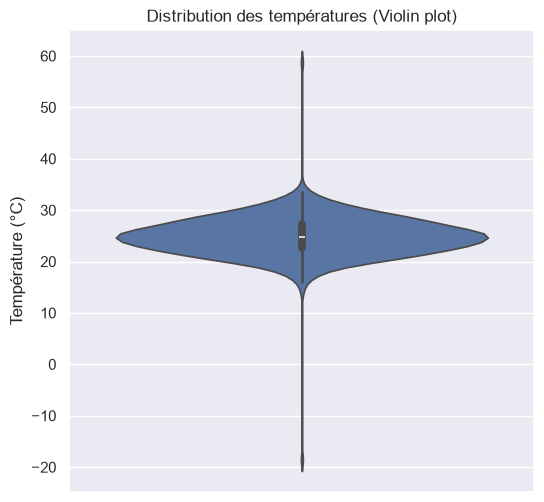

In [21]:
plt.figure(figsize=(6, 6))
sns.violinplot(data=df, y="temperature")
plt.title("Distribution des températures (Violin plot)")
plt.ylabel("Température (°C)")
plt.show()

**2) Afficher la distribution des températures par bâtiment**

C:\Users\other\AppData\Local\Temp\ipykernel_23404\2816146210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="batiment", y="temperature", inner="box", palette="Set1") # inner="box" ajoute une boîte à moustaches à l'intérieur du violon pour montrer la médiane et les quartiles.


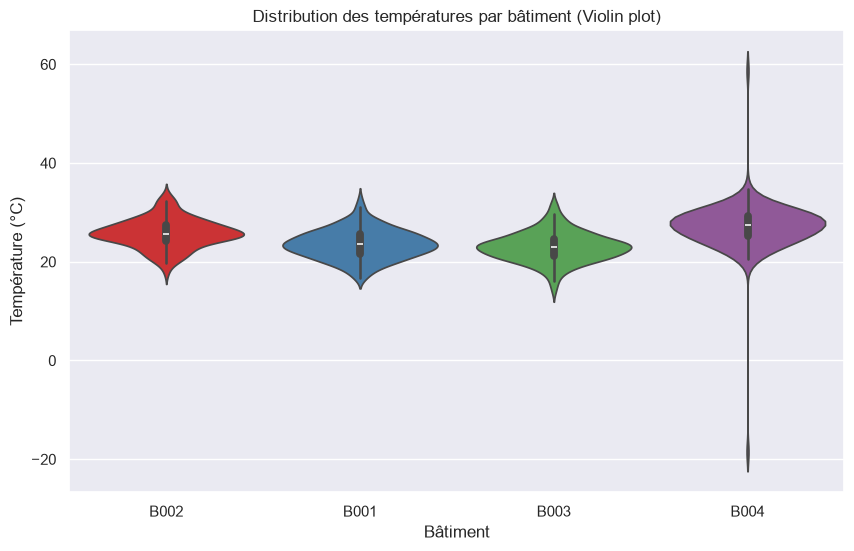

In [26]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="batiment", y="temperature", inner="box", palette="Set1") # inner="box" ajoute une boîte à moustaches à l'intérieur du violon pour montrer la médiane et les quartiles.
plt.title("Distribution des températures par bâtiment (Violin plot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

**3) Quelles informations supplémentaires le violin plot permet-il de visualiser par 
rapport au box plot ?**

Le boxplot donne les valeurs importantes (médiane, quartiles, valeurs extrêmes), tandis que le violin plot montre en plus comment les données sont réparties grâce à la forme de la distribution.